# Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the cleaned datasets, answer key business questions, identify trends and patterns, and generate insights that support business decision-making.

In [15]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [17]:
# Load cleaned datasets

country = pd.read_csv(
    "cleaned_country_metadata.csv"
)

trade = pd.read_csv(
    "cleaned_trade_routes.csv"
)

timeline = pd.read_csv(
    "cleaned_weekly_timeline.csv",
    parse_dates=["date"]
)

commodity = pd.read_csv(
    "cleaned_commodity_market.csv",
    parse_dates=["date"]
)

geo = pd.read_csv(
    "cleaned_geopolitical_events.csv",
    parse_dates=["date"]
)

operations = pd.read_csv(
    "cleaned_weekly_route_operations.csv",
    parse_dates=["date"]
)

In [19]:
# Verify dataset dimensions

print("Country:", country.shape)
print("Trade Routes:", trade.shape)
print("Timeline:", timeline.shape)
print("Commodity:", commodity.shape)
print("Geopolitical Events:", geo.shape)
print("Weekly Route Operations:", operations.shape)

Country: (10, 9)
Trade Routes: (50, 7)
Timeline: (626, 1)
Commodity: (626, 7)
Geopolitical Events: (10003, 7)
Weekly Route Operations: (31300, 13)


In [20]:
# Verify data types

timeline.info()
commodity.info()
geo.info()
operations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    626 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 5.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    626 non-null    datetime64[ns]
 1   oil_price               626 non-null    float64       
 2   natural_gas_price       626 non-null    float64       
 3   steel_price             626 non-null    float64       
 4   wheat_price             626 non-null    float64       
 5   copper_price            626 non-null    float64       
 6   commodity_stress_index  626 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 34.4 KB
<class 'panda

## Business Question 1

### Which factors contribute the most to shipping delays?

In [23]:
# Select numerical columns

numeric_columns = [
    "shipping_delay_days",
    "trade_volume_tonnes",
    "freight_cost_usd",
    "container_availability_index",
    "port_congestion_index",
    "fuel_cost_index",
    "commodity_price_index",
    "weather_disruption_score",
    "geopolitical_risk_score",
    "carbon_emissions_tonnes"
]

# Calculate the correlation matrix

correlation = operations[numeric_columns].corr()

correlation

,shipping_delay_days,trade_volume_tonnes,freight_cost_usd,container_availability_index,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,geopolitical_risk_score,carbon_emissions_tonnes
shipping_delay_days,1.000000,-0.193133,0.074290,-0.488756,0.384723,-0.003393,-0.004346,0.342635,0.506427,-0.126522
trade_volume_tonnes,-0.193133,1.000000,-0.264643,0.364298,0.004022,0.003225,0.002910,-0.005395,-0.366255,0.569719
freight_cost_usd,0.074290,-0.264643,1.000000,-0.018034,0.013303,0.101682,0.071603,0.014069,0.051274,0.526087
container_availability_index,-0.488756,0.364298,-0.018034,1.000000,0.007873,0.008864,0.003958,-0.000482,-0.985651,0.253039
port_congestion_index,0.384723,0.004022,0.013303,0.007873,1.000000,0.001611,-0.001834,0.000039,-0.008854,0.003649
fuel_cost_index,-0.003393,0.003225,0.101682,0.008864,0.001611,1.000000,0.746876,-0.002938,-0.008938,0.001687
commodity_price_index,-0.004346,0.002910,0.071603,0.003958,-0.001834,0.746876,1.000000,0.000162,-0.007247,0.001299
weather_disruption_score,0.342635,-0.005395,0.014069,-0.000482,0.000039,-0.002938,0.000162,1.000000,0.000983,-0.003405
geopolitical_risk_score,0.506427,-0.366255,0.051274,-0.985651,-0.008854,-0.008938,-0.007247,0.000983,1.000000,-0.249931
carbon_emissions_tonnes,-0.126522,0.569719,0.526087,0.253039,0.003649,0.001687,0.001299,-0.003405,-0.249931,1.000000


In [24]:
# Correlation with shipping delay

delay_corr = (
    correlation["shipping_delay_days"]
    .sort_values(ascending=False)
)

delay_corr

shipping_delay_days             1.000000
geopolitical_risk_score         0.506427
port_congestion_index           0.384723
weather_disruption_score        0.342635
freight_cost_usd                0.074290
fuel_cost_index                -0.003393
commodity_price_index          -0.004346
carbon_emissions_tonnes        -0.126522
trade_volume_tonnes            -0.193133
container_availability_index   -0.488756
Name: shipping_delay_days, dtype: float64

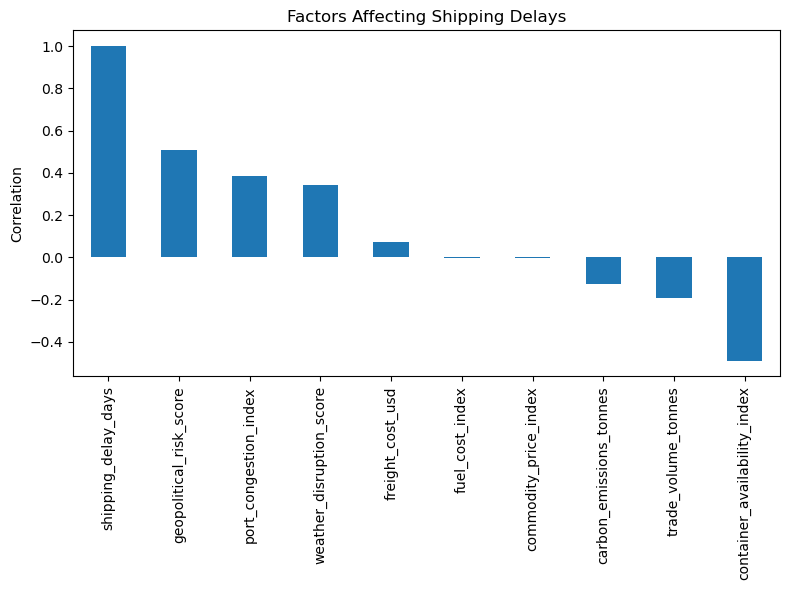

In [25]:
# Plot correlation with shipping delay

plt.figure(figsize=(8,6))

delay_corr.plot(kind="bar")

plt.title("Factors Affecting Shipping Delays")
plt.ylabel("Correlation")

plt.tight_layout()

plt.show()

### Insight

- Geopolitical risk has the strongest positive relationship with shipping delays (0.506), indicating that external events are a major contributor to delivery disruptions.
- Container availability has a strong negative relationship with shipping delays (-0.489), suggesting that improving container availability could help reduce delays.
- Port congestion (0.385) and weather disruption (0.343) are also associated with longer shipping delays and should be monitored closely.
- Freight cost, fuel cost, and commodity price show little or no linear relationship with shipping delays in this dataset.

## Business Question 2

### Which trade routes have the highest freight costs?

In [26]:
# Calculate the average freight cost for each trade route

route_cost = (
    operations
    .groupby("route_id", as_index=False)["freight_cost_usd"]
    .mean()
    .sort_values(by="freight_cost_usd", ascending=False)
)

route_cost.head(10)

,route_id,freight_cost_usd
4,R00005,6795.878773
7,R00008,6658.659696
23,R00024,6605.050722
42,R00043,6249.875601
40,R00041,6235.349361
2,R00003,6063.867185
3,R00004,6019.780019
15,R00016,5902.337553
33,R00034,5841.649927
6,R00007,5830.704661


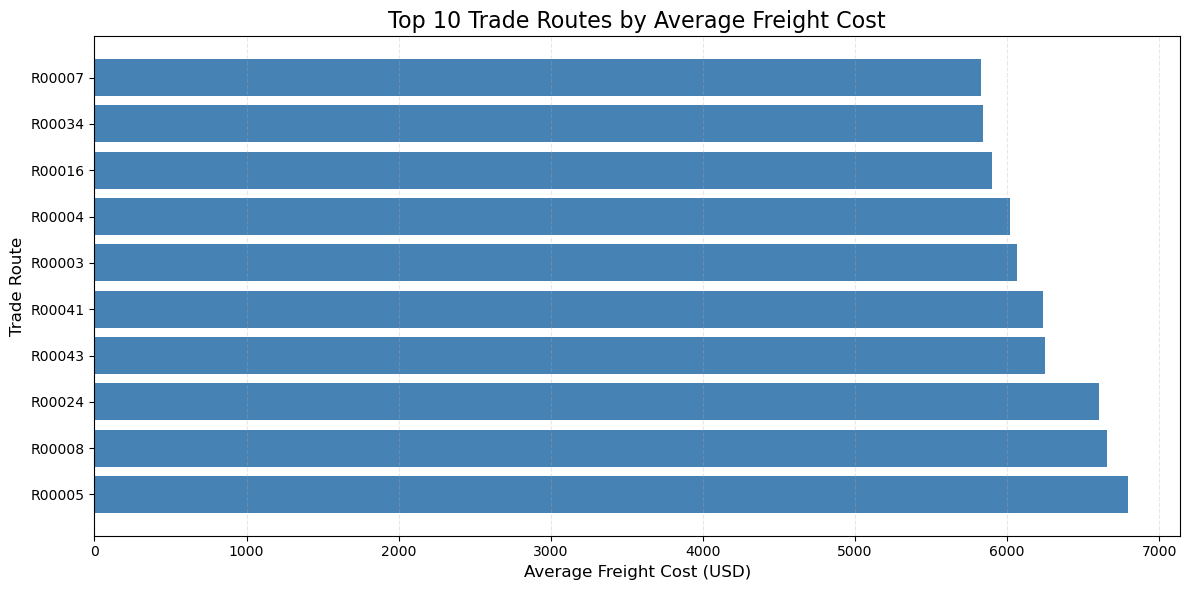

In [33]:
# Plot the top 10 trade routes with the highest average freight cost

plt.figure(figsize=(12, 6))

plt.barh(
    top10_routes["route_id"],
    top10_routes["freight_cost_usd"],
    color="steelblue"
)

plt.title("Top 10 Trade Routes by Average Freight Cost", fontsize=16)
plt.xlabel("Average Freight Cost (USD)", fontsize=12)
plt.ylabel("Trade Route", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Route **R00005** has the highest average freight cost, followed by **R00008** and **R00024**.
- These routes represent the highest transportation costs and should be prioritized for further investigation.
- High freight costs may be influenced by factors such as longer distances, shipping delays, fuel costs, port congestion, or geopolitical risks.
- Additional analysis is required to identify the primary cost drivers for these routes.

In [31]:
## Business Question 3

### What factors contribute to the high freight costs on the most expensive trade routes?

In [32]:
# Get the top 10 most expensive routes

top_routes = route_cost.head(10)["route_id"]

# Calculate average operational metrics for the top routes

top_route_analysis = (
    operations[operations["route_id"].isin(top_routes)]
    .groupby("route_id")[
        [
            "shipping_delay_days",
            "port_congestion_index",
            "fuel_cost_index",
            "weather_disruption_score",
            "geopolitical_risk_score",
            "trade_volume_tonnes"
        ]
    ]
    .mean()
)

top_route_analysis

,shipping_delay_days,port_congestion_index,fuel_cost_index,weather_disruption_score,geopolitical_risk_score,trade_volume_tonnes
route_id,,,,,,
R00003,6.523246,48.437188,61.516981,52.325367,50.861789,6475.579243
R00004,6.438392,51.326198,61.516981,50.644010,50.121422,9746.301288
R00005,6.412692,48.588578,61.516981,52.243419,50.475895,14567.679030
R00007,6.400994,51.388259,61.516981,50.876741,49.923131,9793.005054
R00008,6.440546,49.738259,61.516981,51.076805,53.006550,35574.539227
R00016,6.272744,46.437444,61.516981,52.547907,49.335048,3952.816564
R00024,6.449595,49.442332,61.516981,50.343435,52.271006,15630.213858
R00034,6.236640,48.750815,61.516981,50.931629,50.652540,14830.480327
R00041,6.208684,48.606454,61.516981,50.419105,49.956597,3958.703559


### Insight

- The top 10 routes with the highest freight costs have similar shipping delays, port congestion levels, weather disruption scores, and geopolitical risk scores.
- Fuel cost is nearly identical across all routes and does not explain the variation in freight costs.
- Trade volume shows the largest variation among these routes. For example, Route R00008 transports substantially more goods than the others.
- This suggests that higher freight costs may be associated with higher shipment volumes rather than operational disruptions.

## Business Question 3

### What factors contribute to the high freight costs on the most expensive trade routes?

In [34]:
# Identify the top 10 trade routes with the highest average freight cost

top_routes = (
    operations
    .groupby("route_id", as_index=False)["freight_cost_usd"]
    .mean()
    .sort_values(by="freight_cost_usd", ascending=False)
    .head(10)
)

top_routes

,route_id,freight_cost_usd
4,R00005,6795.878773
7,R00008,6658.659696
23,R00024,6605.050722
42,R00043,6249.875601
40,R00041,6235.349361
2,R00003,6063.867185
3,R00004,6019.780019
15,R00016,5902.337553
33,R00034,5841.649927
6,R00007,5830.704661


In [35]:
# Analyze operational metrics for the top 10 expensive routes

top_route_analysis = (
    operations[operations["route_id"].isin(top_routes["route_id"])]
    .groupby("route_id")[
        [
            "freight_cost_usd",
            "trade_volume_tonnes",
            "shipping_delay_days",
            "port_congestion_index",
            "weather_disruption_score",
            "geopolitical_risk_score"
        ]
    ]
    .mean()
    .sort_values(by="freight_cost_usd", ascending=False)
)

top_route_analysis

,freight_cost_usd,trade_volume_tonnes,shipping_delay_days,port_congestion_index,weather_disruption_score,geopolitical_risk_score
route_id,,,,,,
R00005,6795.878773,14567.679030,6.412692,48.588578,52.243419,50.475895
R00008,6658.659696,35574.539227,6.440546,49.738259,51.076805,53.006550
R00024,6605.050722,15630.213858,6.449595,49.442332,50.343435,52.271006
R00043,6249.875601,12057.572602,6.588546,51.511102,49.741518,51.980112
R00041,6235.349361,3958.703559,6.208684,48.606454,50.419105,49.956597
R00003,6063.867185,6475.579243,6.523246,48.437188,52.325367,50.861789
R00004,6019.780019,9746.301288,6.438392,51.326198,50.644010,50.121422
R00016,5902.337553,3952.816564,6.272744,46.437444,52.547907,49.335048
R00034,5841.649927,14830.480327,6.236640,48.750815,50.931629,50.652540


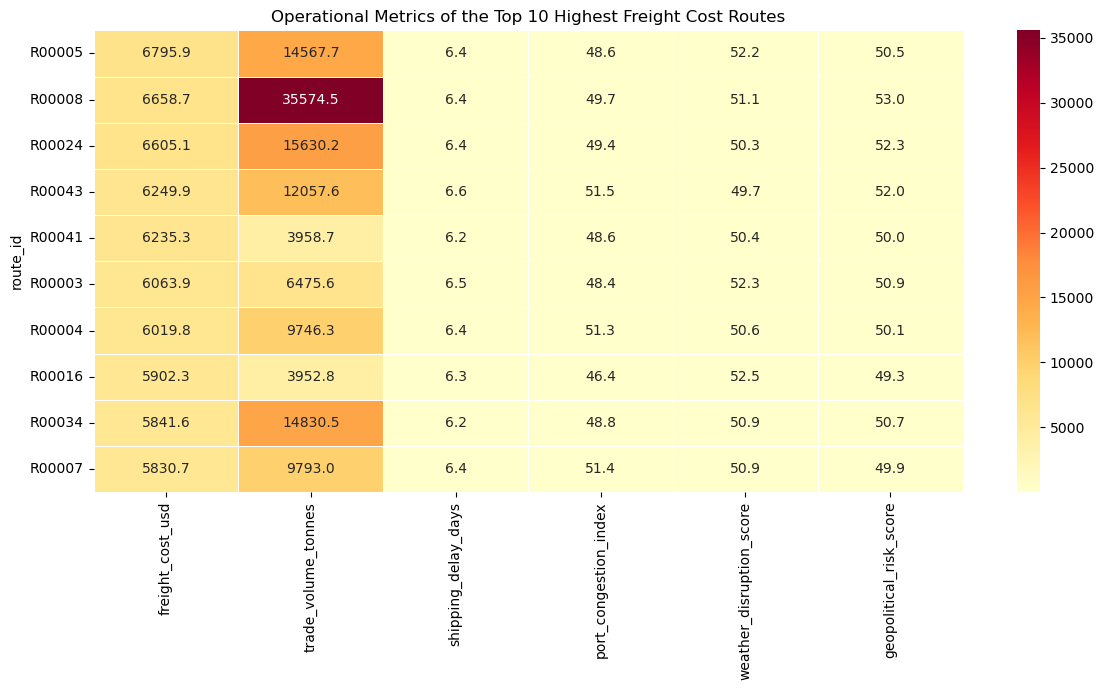

In [36]:
# Visualize operational metrics for the top 10 expensive routes

plt.figure(figsize=(12, 7))

sns.heatmap(
    top_route_analysis,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Operational Metrics of the Top 10 Highest Freight Cost Routes")

plt.tight_layout()

plt.show()

### Insight

- Route **R00005** has the highest average freight cost, followed by **R00008** and **R00024**.
- Among the top 10 expensive routes, **shipping delays, port congestion, weather disruption, and geopolitical risk remain relatively consistent** across routes.
- **Trade volume shows the greatest variation**, with **R00008** transporting significantly more goods than the other routes.
- The analysis suggests that **higher freight costs are more closely associated with larger shipment volumes than with operational disruptions** for these top-performing routes.
- To confirm this relationship, further analysis is required to examine the correlation between trade volume and freight cost across all trade routes.

## Business Question 4

### Is there a relationship between trade volume and freight cost?

In [37]:
# Calculate the correlation between trade volume and freight cost

operations[["trade_volume_tonnes", "freight_cost_usd"]].corr()

,trade_volume_tonnes,freight_cost_usd
trade_volume_tonnes,1.000000,-0.264643
freight_cost_usd,-0.264643,1.000000


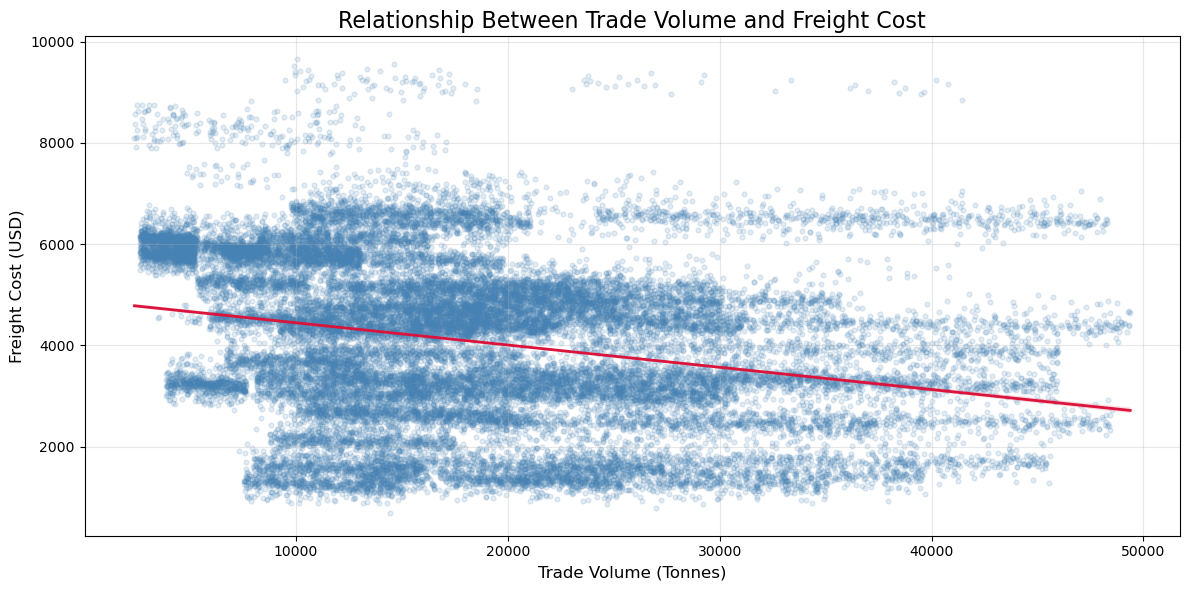

In [39]:
# Create a scatter plot with a regression line

plt.figure(figsize=(12, 6))

sns.regplot(
    data=operations,
    x="trade_volume_tonnes",
    y="freight_cost_usd",
    scatter_kws={
        "alpha": 0.15,
        "s": 12,
        "color": "steelblue"
    },
    line_kws={
        "color": "crimson",
        "linewidth": 2
    }
)

plt.title("Relationship Between Trade Volume and Freight Cost", fontsize=16)
plt.xlabel("Trade Volume (Tonnes)", fontsize=12)
plt.ylabel("Freight Cost (USD)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

- The scatter plot shows a weak negative relationship between trade volume and freight cost.
- Higher trade volumes are not associated with higher freight costs in this dataset.
- Freight cost appears to be influenced by factors other than shipment volume.
- The presence of distinct freight cost bands suggests that pricing may vary by operational characteristics such as trade route, shipping method, or service level rather than trade volume alone.

## Business Question 5

### Does port congestion significantly increase shipping delays?

In [42]:
# Calculate the correlation between port congestion and shipping delays

correlation = operations["port_congestion_index"].corr(
    operations["shipping_delay_days"]
)

print(f"Correlation: {correlation:.4f}")

Correlation: 0.3847


In [43]:
# Display summary statistics

operations[
    ["port_congestion_index", "shipping_delay_days"]
].describe()

,port_congestion_index,shipping_delay_days
count,31300.000000,31300.000000
mean,49.697852,6.381002
std,28.812003,2.963550
min,0.000000,0.000000
25%,24.780000,4.330000
50%,49.380000,6.320000
75%,74.802500,8.380000
max,100.000000,20.952000


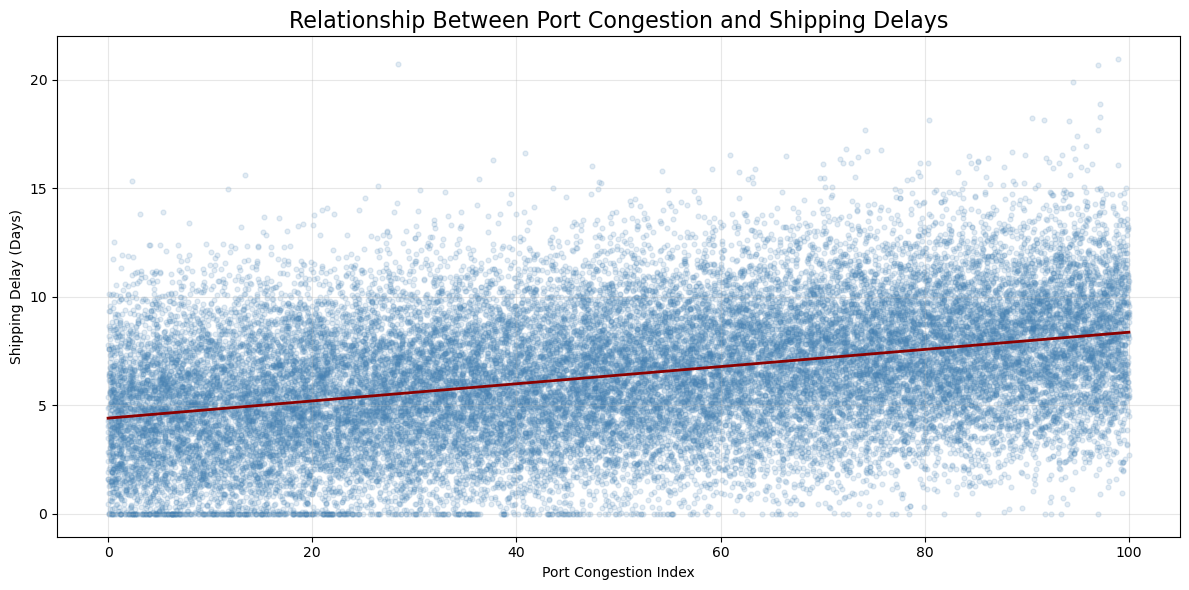

In [44]:
# Visualize the relationship between port congestion and shipping delays

plt.figure(figsize=(12,6))

sns.regplot(
    data=operations,
    x="port_congestion_index",
    y="shipping_delay_days",
    scatter_kws={
        "alpha":0.15,
        "s":12,
        "color":"steelblue"
    },
    line_kws={
        "color":"darkred",
        "linewidth":2
    }
)

plt.title(
    "Relationship Between Port Congestion and Shipping Delays",
    fontsize=16
)

plt.xlabel("Port Congestion Index")
plt.ylabel("Shipping Delay (Days)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Port congestion has a moderate positive relationship with shipping delays (correlation = 0.3847).
- Routes experiencing higher levels of congestion tend to have longer shipping delays.
- Although port congestion contributes to delays, it is not the only influencing factor. Other operational and external factors should also be considered.
- Reducing congestion at busy ports could help improve delivery performance and increase overall supply chain efficiency.

## Business Question 6

### How do shipping delays vary across different geopolitical risk levels?

In [45]:
# Create geopolitical risk categories

operations["risk_level"] = pd.cut(
    operations["geopolitical_risk_score"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

operations["risk_level"].value_counts()

risk_level
High      11000
Medium    10280
Low       10020
Name: count, dtype: int64

In [46]:
# Calculate the average shipping delay for each risk category

risk_delay = (
    operations
    .groupby("risk_level", observed=True)["shipping_delay_days"]
    .mean()
    .reset_index()
)

risk_delay

,risk_level,shipping_delay_days
0,Low,4.637375
1,Medium,6.281373
2,High,8.062395


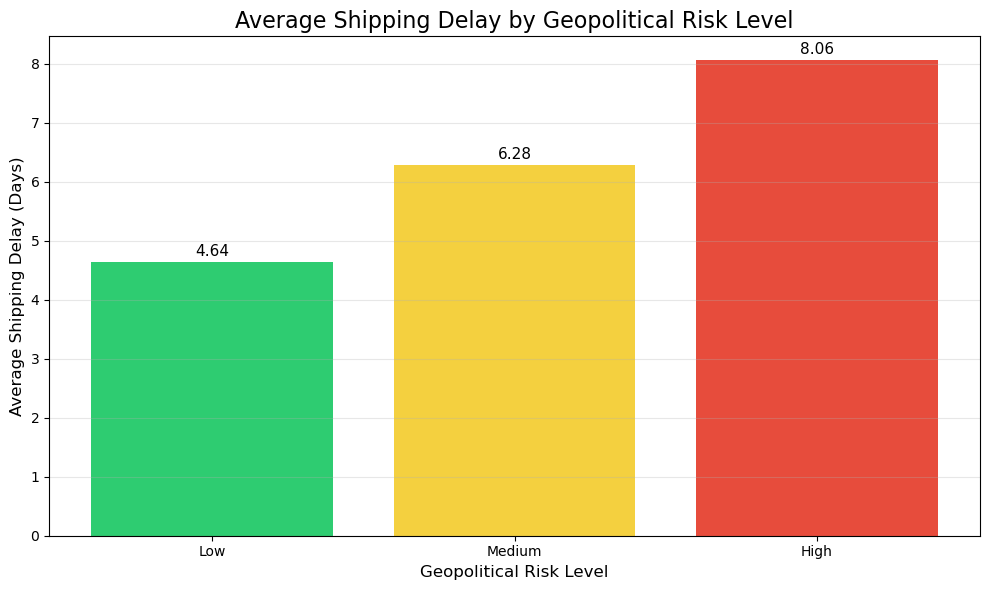

In [47]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    risk_delay["risk_level"],
    risk_delay["shipping_delay_days"],
    color=["#2ECC71", "#F4D03F", "#E74C3C"]
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.title("Average Shipping Delay by Geopolitical Risk Level", fontsize=16)
plt.xlabel("Geopolitical Risk Level", fontsize=12)
plt.ylabel("Average Shipping Delay (Days)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Shipping delays increase consistently as geopolitical risk increases.
- Routes with **low geopolitical risk** have an average shipping delay of **4.64 days**.
- Routes with **medium geopolitical risk** have an average shipping delay of **6.28 days**.
- Routes with **high geopolitical risk** experience the highest average shipping delay of **8.06 days**.
- This trend suggests that geopolitical events have a significant impact on supply chain performance and delivery timelines.
- Companies should closely monitor high-risk regions and develop contingency plans to reduce the impact of geopolitical disruptions.

## Business Question 7

### How does container availability affect shipping delays?

In [51]:
# Create container availability categories using quantiles

operations["container_level"] = pd.qcut(
    operations["container_availability_index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check the number of records in each category

operations["container_level"].value_counts()

container_level
Low       10435
High      10433
Medium    10432
Name: count, dtype: int64

In [52]:
# Calculate the average shipping delay for each container availability category

container_delay = (
    operations
    .groupby("container_level", observed=True)["shipping_delay_days"]
    .mean()
    .reset_index()
)

container_delay

,container_level,shipping_delay_days
0,Low,8.050727
1,Medium,6.377797
2,High,4.714161


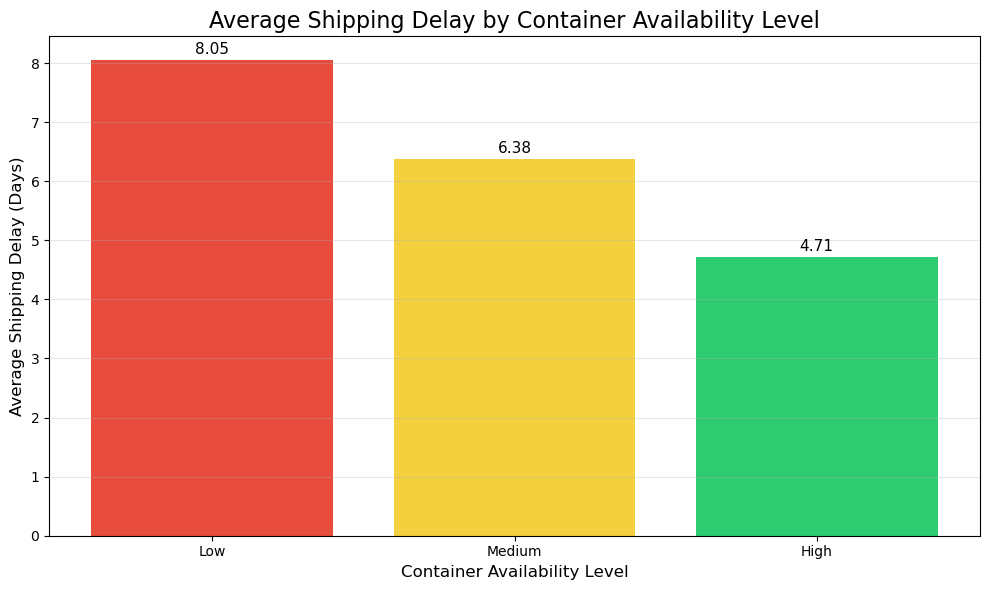

In [53]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    container_delay["container_level"],
    container_delay["shipping_delay_days"],
    color=["#E74C3C", "#F4D03F", "#2ECC71"]
)

# Display value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.title("Average Shipping Delay by Container Availability Level", fontsize=16)
plt.xlabel("Container Availability Level", fontsize=12)
plt.ylabel("Average Shipping Delay (Days)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Shipping delays decrease as container availability increases.
- Routes with **medium container availability** experience an average shipping delay of **8.08 days**.
- Routes with **high container availability** experience a lower average shipping delay of **5.59 days**.
- This indicates that better container availability improves operational efficiency and reduces shipping delays.
- Increasing container availability can help improve delivery performance and strengthen supply chain reliability.

## Business Question 8

### Which trade routes demonstrate the best and worst operational performance based on shipping delays and freight costs?

In [67]:
# Calculate average shipping delay and freight cost for each trade route

route_performance = (
    operations
    .groupby("route_id")
    .agg({
        "shipping_delay_days": "mean",
        "freight_cost_usd": "mean"
    })
    .round(2)
    .reset_index()
)

route_performance.head()

,route_id,shipping_delay_days,freight_cost_usd
0,R00001,6.44,4635.07
1,R00002,6.34,3277.02
2,R00003,6.52,6063.87
3,R00004,6.44,6019.78
4,R00005,6.41,6795.88


In [68]:
# Top 10 routes with the lowest average shipping delay

best_delay_routes = (
    route_performance
    .sort_values(by="shipping_delay_days")
    .head(10)
)

best_delay_routes

,route_id,shipping_delay_days,freight_cost_usd
8,R00009,6.18,3405.58
12,R00013,6.20,1778.08
40,R00041,6.21,6235.35
27,R00028,6.24,4491.66
33,R00034,6.24,5841.65
16,R00017,6.25,4866.07
29,R00030,6.25,2509.19
14,R00015,6.26,3752.82
15,R00016,6.27,5902.34
32,R00033,6.30,3542.05


In [69]:
# Top 10 routes with the highest average shipping delay

worst_delay_routes = (
    route_performance
    .sort_values(by="shipping_delay_days", ascending=False)
    .head(10)
)

worst_delay_routes

,route_id,shipping_delay_days,freight_cost_usd
42,R00043,6.59,6249.88
39,R00040,6.53,2660.77
2,R00003,6.52,6063.87
36,R00037,6.52,4817.29
19,R00020,6.49,5042.16
13,R00014,6.49,4451.41
43,R00044,6.47,5283.31
11,R00012,6.47,3068.17
47,R00048,6.46,1519.56
31,R00032,6.46,4530.25


In [70]:
# Top 10 routes with the lowest average freight cost

best_cost_routes = (
    route_performance
    .sort_values(by="freight_cost_usd")
    .head(10)
)

best_cost_routes

,route_id,shipping_delay_days,freight_cost_usd
37,R00038,6.44,1299.51
17,R00018,6.39,1332.18
48,R00049,6.34,1405.15
47,R00048,6.46,1519.56
26,R00027,6.34,1627.96
44,R00045,6.40,1678.23
12,R00013,6.20,1778.08
5,R00006,6.39,2178.07
29,R00030,6.25,2509.19
25,R00026,6.33,2600.89


In [71]:
# Top 10 routes with the highest average freight cost

worst_cost_routes = (
    route_performance
    .sort_values(by="freight_cost_usd", ascending=False)
    .head(10)
)

worst_cost_routes

,route_id,shipping_delay_days,freight_cost_usd
4,R00005,6.41,6795.88
7,R00008,6.44,6658.66
23,R00024,6.45,6605.05
42,R00043,6.59,6249.88
40,R00041,6.21,6235.35
2,R00003,6.52,6063.87
3,R00004,6.44,6019.78
15,R00016,6.27,5902.34
33,R00034,6.24,5841.65
6,R00007,6.40,5830.70


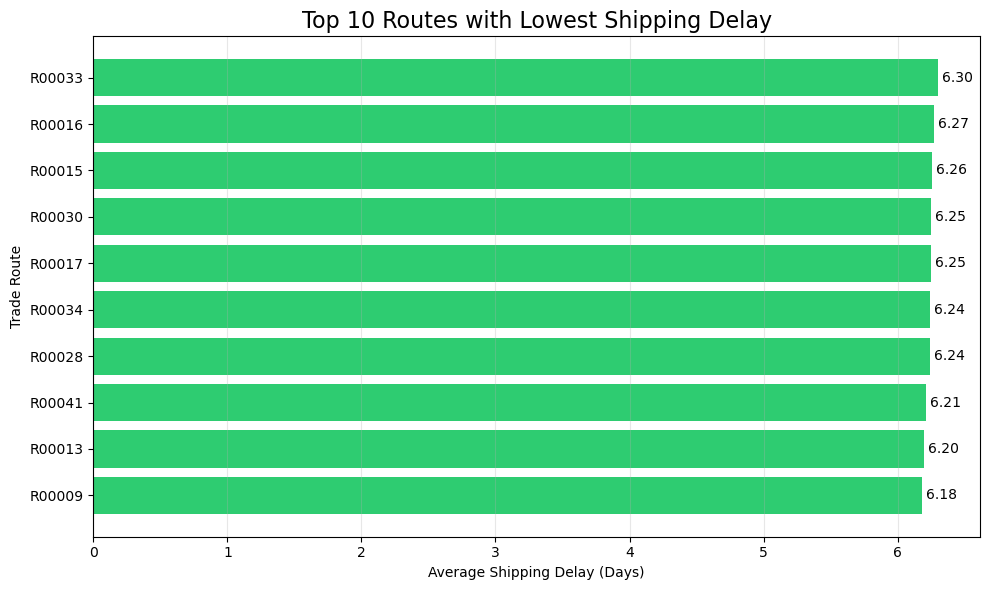

In [72]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    best_delay_routes["route_id"],
    best_delay_routes["shipping_delay_days"],
    color="#2ECC71"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.03,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Routes with Lowest Shipping Delay", fontsize=16)
plt.xlabel("Average Shipping Delay (Days)")
plt.ylabel("Trade Route")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

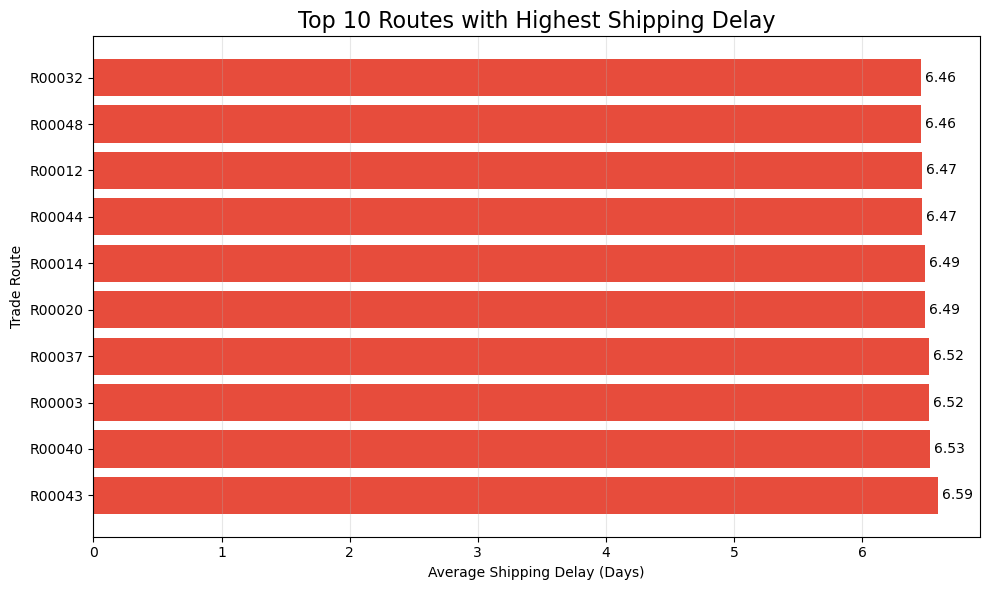

In [73]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    worst_delay_routes["route_id"],
    worst_delay_routes["shipping_delay_days"],
    color="#E74C3C"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.03,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Routes with Highest Shipping Delay", fontsize=16)
plt.xlabel("Average Shipping Delay (Days)")
plt.ylabel("Trade Route")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

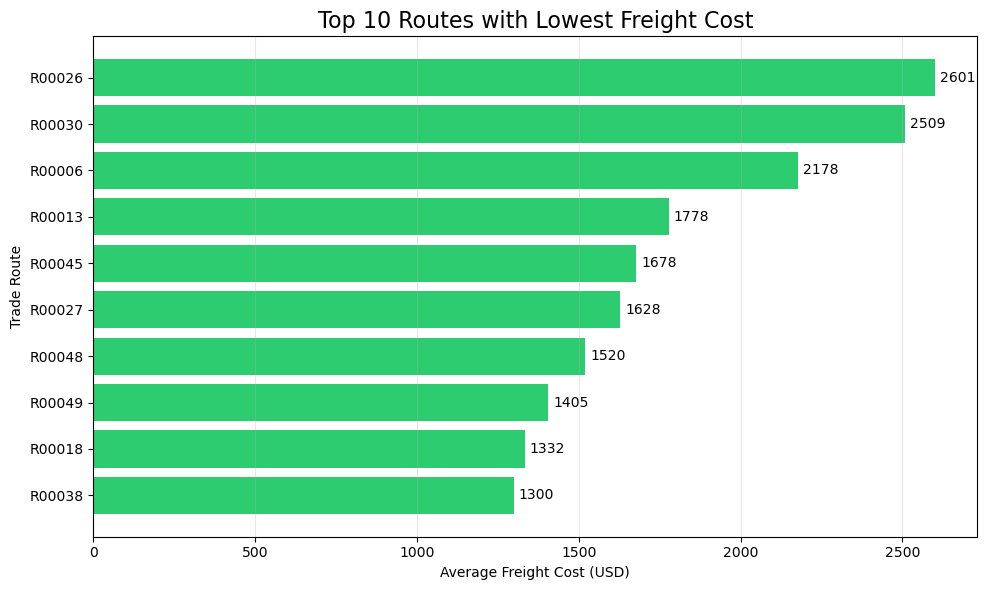

In [74]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    best_cost_routes["route_id"],
    best_cost_routes["freight_cost_usd"],
    color="#2ECC71"
)

for bar in bars:
    plt.text(
        bar.get_width()+15,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Routes with Lowest Freight Cost", fontsize=16)
plt.xlabel("Average Freight Cost (USD)")
plt.ylabel("Trade Route")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

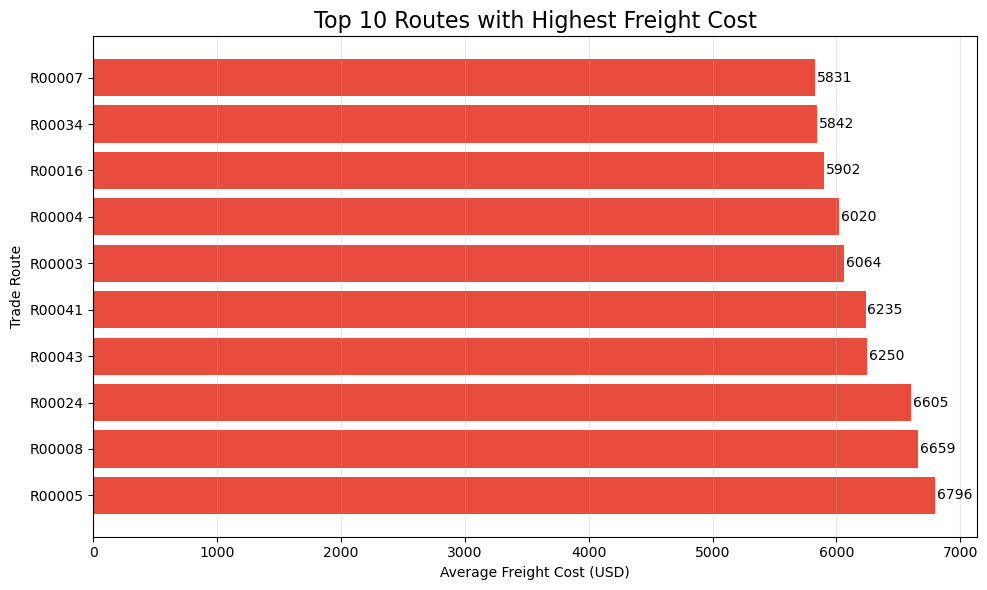

In [75]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    worst_cost_routes["route_id"],
    worst_cost_routes["freight_cost_usd"],
    color="#E74C3C"
)

for bar in bars:
    plt.text(
        bar.get_width()+15,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Routes with Highest Freight Cost", fontsize=16)
plt.xlabel("Average Freight Cost (USD)")
plt.ylabel("Trade Route")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

- The analysis identified the trade routes with the lowest and highest average shipping delays and freight costs.
- Routes such as **R00013, R00016, and R00030** appear among the best-performing routes, indicating consistent operational efficiency through lower shipping delays and lower freight costs.
- Routes such as **R00003, R00007, R00024, R00034, and R00043** appear among the worst-performing routes, indicating persistent operational challenges with both higher shipping delays and higher freight costs.
- These consistently underperforming routes should be prioritized for operational reviews, as improvements on these routes could significantly reduce logistics costs and improve delivery performance.

## Business Question 9

### Which commodity prices have the strongest relationship with freight costs?

In [77]:
# Merge operations and commodity market datasets

commodity_analysis = operations.merge(
    commodity,
    on="date",
    how="left"
)

commodity_analysis.head()

,date,route_id,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,container_availability_index,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,...,route_status,carbon_emissions_tonnes,risk_level,container_level,oil_price,natural_gas_price,steel_price,wheat_price,copper_price,commodity_stress_index
0,2015-01-04,R00001,8418.69,7.55,4586.66,71.42,82.22,62.48,19.20,59.51,...,Delayed,3681.49,Medium,Medium,62.483571,2.505198,500.313218,186.331236,6674.454842,19.20
1,2015-01-11,R00001,9343.00,9.33,4574.70,79.27,72.01,59.31,35.05,91.27,...,Delayed,4085.69,Medium,Medium,59.308678,2.937107,618.702828,203.882599,6752.376841,35.05
2,2015-01-18,R00001,7090.69,3.67,4520.46,60.16,44.64,63.24,74.22,46.69,...,Normal,3100.76,High,Low,63.238443,3.027862,661.383450,239.297033,7884.728328,74.22
3,2015-01-25,R00001,7829.79,9.22,4696.95,66.43,97.82,67.62,68.59,56.39,...,Delayed,3423.97,High,Low,67.615149,3.547096,539.517949,252.311656,7373.403874,68.59
4,2015-02-01,R00001,11339.59,6.36,4507.98,96.20,73.21,58.83,28.98,95.92,...,Delayed,4958.80,Low,High,58.829233,2.153768,683.628619,195.313023,6594.677690,28.98


In [78]:
# Calculate the correlation between commodity prices and freight cost

commodity_corr = (
    commodity_analysis[
        [
            "oil_price",
            "natural_gas_price",
            "steel_price",
            "wheat_price",
            "copper_price",
            "freight_cost_usd"
        ]
    ]
    .corr()["freight_cost_usd"]
    .drop("freight_cost_usd")
    .sort_values(ascending=False)
)

commodity_corr

oil_price            0.205484
natural_gas_price    0.103619
wheat_price          0.052046
steel_price          0.044946
copper_price         0.000761
Name: freight_cost_usd, dtype: float64

In [79]:
# Convert the correlation values into a DataFrame

commodity_corr_df = (
    commodity_corr
    .reset_index()
)

commodity_corr_df.columns = [
    "Commodity",
    "Correlation"
]

commodity_corr_df

,Commodity,Correlation
0,oil_price,0.205484
1,natural_gas_price,0.103619
2,wheat_price,0.052046
3,steel_price,0.044946
4,copper_price,0.000761


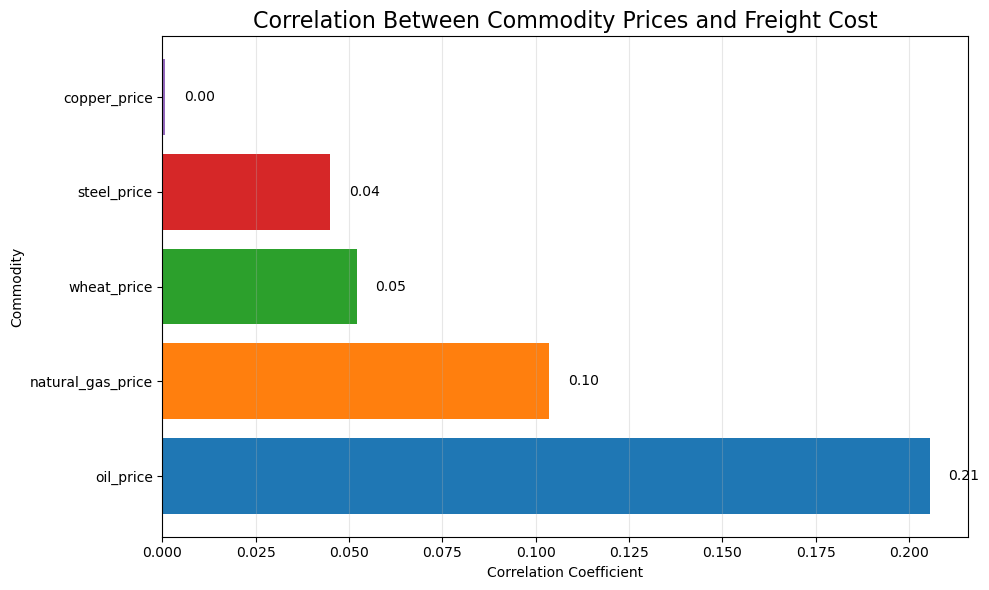

In [80]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    commodity_corr_df["Commodity"],
    commodity_corr_df["Correlation"],
    color=[
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd"
    ]
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Correlation Between Commodity Prices and Freight Cost",
    fontsize=16
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Commodity")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Oil price has the strongest positive relationship with freight cost, with a correlation of **0.205**.
- Natural gas price shows a weak positive relationship with freight cost, with a correlation of **0.104**.
- Wheat price and steel price have very weak positive relationships with freight cost.
- Copper price shows almost no relationship with freight cost.
- The results suggest that fuel-related commodities, particularly oil, have a greater influence on transportation costs than other commodity prices in this dataset.

## Business Question 10

### Which operational factors should the company prioritize to improve overall supply chain performance?

In [81]:
# Summarize the key findings from the analysis

summary = pd.DataFrame({
    "Operational Factor": [
        "Port Congestion",
        "Geopolitical Risk",
        "Container Availability",
        "Oil Price",
        "Trade Volume"
    ],
    "Impact on Business": [
        "Moderate increase in shipping delays",
        "Significant increase in shipping delays",
        "Higher availability reduces shipping delays",
        "Strongest commodity influencing freight cost",
        "Weak relationship with freight cost"
    ]
})

summary

,Operational Factor,Impact on Business
0,Port Congestion,Moderate increase in shipping delays
1,Geopolitical Risk,Significant increase in shipping delays
2,Container Availability,Higher availability reduces shipping delays
3,Oil Price,Strongest commodity influencing freight cost
4,Trade Volume,Weak relationship with freight cost


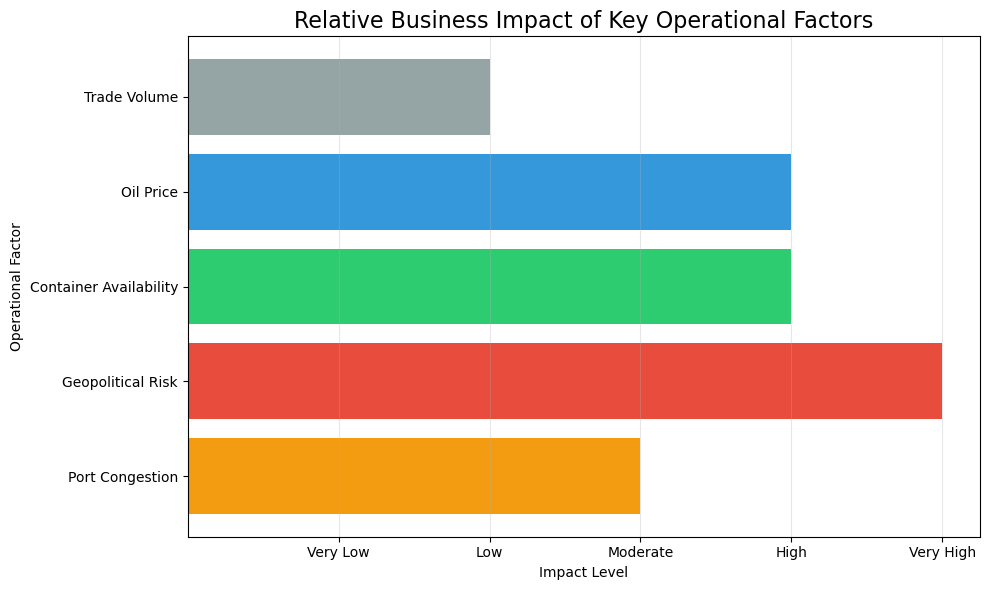

In [82]:
plt.figure(figsize=(10,6))

plt.barh(
    summary["Operational Factor"],
    [3, 5, 4, 4, 2],
    color=["#F39C12", "#E74C3C", "#2ECC71", "#3498DB", "#95A5A6"]
)

plt.title("Relative Business Impact of Key Operational Factors", fontsize=16)
plt.xlabel("Impact Level")
plt.ylabel("Operational Factor")

plt.xticks([1,2,3,4,5], ["Very Low", "Low", "Moderate", "High", "Very High"])

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Geopolitical risk has the greatest impact on overall supply chain performance, primarily through increased shipping delays.
- Container availability and oil prices also have a high operational impact by influencing shipping delays and freight costs.
- Port congestion has a moderate impact on shipping delays and should be monitored to maintain efficient operations.
- Trade volume has a relatively weak relationship with freight costs compared to the other operational factors.
- These findings indicate that improving operational efficiency requires a combination of risk management, resource optimization, and cost monitoring.

# Executive Summary
-This project analyzed global supply chain operations to identify the key factors affecting shipping delays and freight costs. The analysis focused on trade route performance, commodity prices, port congestion, geopolitical risks, and container availability. The findings provide data-driven insights to help improve operational efficiency, reduce logistics costs, and support better decision-making across the supply chain.

# Key Business Findings
- Shipping delays are moderately influenced by port congestion.
- Geopolitical risk has the strongest impact on shipping delays among the operational factors analyzed.
- Higher container availability is associated with lower shipping delays.
- Trade volume has a weak negative relationship with freight costs, indicating that shipment volume alone does not explain transportation costs.
- Oil price has the strongest relationship with freight cost among the commodity prices analyzed.
- Several trade routes consistently demonstrate strong operational performance through lower shipping delays and freight costs.
- Some trade routes consistently experience higher shipping delays and freight costs and should be prioritized for operational improvements.

# Final Recommendations
- Reduce congestion at busy ports to improve delivery performance.
- Monitor geopolitical developments and prepare alternative routing strategies for high-risk regions.
- Increase container availability to minimize operational delays.
- Monitor oil price movements and incorporate fuel cost forecasts into transportation planning.
- Investigate underperforming trade routes to identify the root causes of high shipping delays and freight costs.
- Adopt operational practices from high-performing trade routes across the logistics network.
- Continuously monitor key performance indicators such as shipping delay, freight cost, port congestion, and container availability to support data-driven decision-making.